In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

uploading of Data

In [3]:
data = pd.read_excel('uber_data.xlsx')
print("Total rows:", len(data))
print("Total columns:", len(data.columns))
data.head()


Total rows: 150000
Total columns: 21


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [5]:
data.shape

(150000, 21)

In [6]:
data.columns.tolist()

['Date',
 'Time',
 'Booking ID',
 'Booking Status',
 'Customer ID',
 'Vehicle Type',
 'Pickup Location',
 'Drop Location',
 'Avg VTAT',
 'Avg CTAT',
 'Cancelled Rides by Customer',
 'Reason for cancelling by Customer',
 'Cancelled Rides by Driver',
 'Driver Cancellation Reason',
 'Incomplete Rides',
 'Incomplete Rides Reason',
 'Booking Value',
 'Ride Distance',
 'Driver Ratings',
 'Customer Rating',
 'Payment Method']

In [7]:
data.isnull().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

In [10]:
data['DateTime'] = pd.to_datetime(data['Date'].astype(str) + ' ' + data['Time'].astype(str))

In [11]:
data['hour']    = data['DateTime'].dt.hour
data['day']     = data['DateTime'].dt.day
data['month']   = data['DateTime'].dt.month
data['weekday'] = data['DateTime'].dt.day_name()
data[['Date', 'Time', 'DateTime', 'hour', 'day', 'month', 'weekday']].head()

,Date,Time,DateTime,hour,day,month,weekday
0,2024-03-23,12:29:38,2024-03-23 12:29:38,12,23,3,Saturday
1,2024-11-29,18:01:39,2024-11-29 18:01:39,18,29,11,Friday
2,2024-08-23,08:56:10,2024-08-23 08:56:10,8,23,8,Friday
3,2024-10-21,17:17:25,2024-10-21 17:17:25,17,21,10,Monday
4,2024-09-16,22:08:00,2024-09-16 22:08:00,22,16,9,Monday


In [12]:
data['Booking Status'].value_counts()

Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

In [13]:
data['Vehicle Type'].value_counts()

Vehicle Type
Auto             37419
Go Mini          29806
Go Sedan         27141
Bike             22517
Premier Sedan    18111
eBike            10557
Uber XL           4449
Name: count, dtype: int64

In [14]:
data.shape
data.dtypes

Date                                 datetime64[ns]
Time                                         object
Booking ID                                   object
Booking Status                               object
Customer ID                                  object
Vehicle Type                                 object
Pickup Location                              object
Drop Location                                object
Avg VTAT                                    float64
Avg CTAT                                    float64
Cancelled Rides by Customer                 float64
Reason for cancelling by Customer            object
Cancelled Rides by Driver                   float64
Driver Cancellation Reason                   object
Incomplete Rides                            float64
Incomplete Rides Reason                      object
Booking Value                               float64
Ride Distance                               float64
Driver Ratings                              float64
Customer Rat

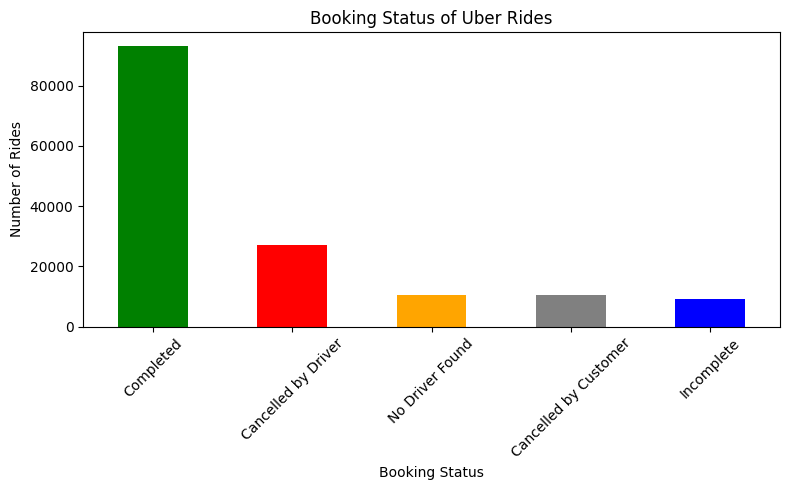

In [16]:
plt.figure(figsize=(8, 5))
status_counts = data['Booking Status'].value_counts()
colors = ['green', 'red', 'orange', 'gray', 'blue']

status_counts.plot(kind='bar', color=colors)

plt.title('Booking Status of Uber Rides')
plt.xlabel('Booking Status')
plt.ylabel('Number of Rides')
plt.xticks(rotation=45)  
plt.tight_layout()
plt.savefig('outputs/booking_status.png')

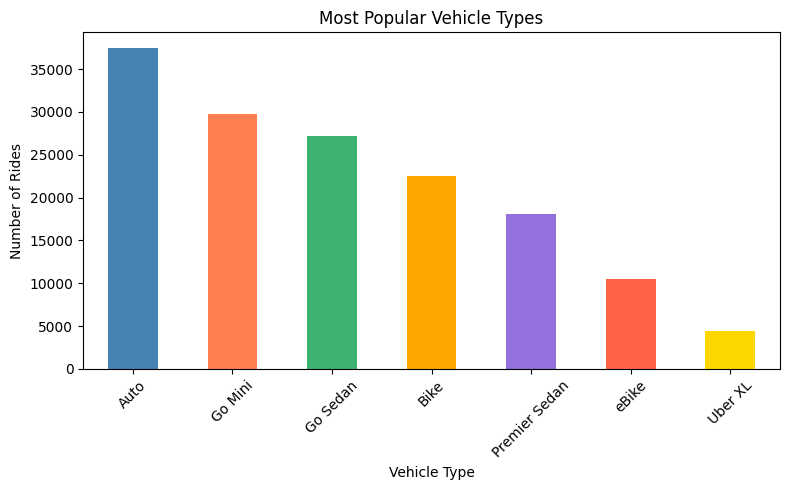

In [17]:
plt.figure(figsize=(8, 5))

vehicle_counts = data['Vehicle Type'].value_counts()

colors = ['steelblue', 'coral', 'mediumseagreen', 
          'orange', 'mediumpurple', 'tomato', 'gold']

vehicle_counts.plot(kind='bar', color=colors)

plt.title('Most Popular Vehicle Types')
plt.xlabel('Vehicle Type')
plt.ylabel('Number of Rides')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('outputs/vehicle_types.png')


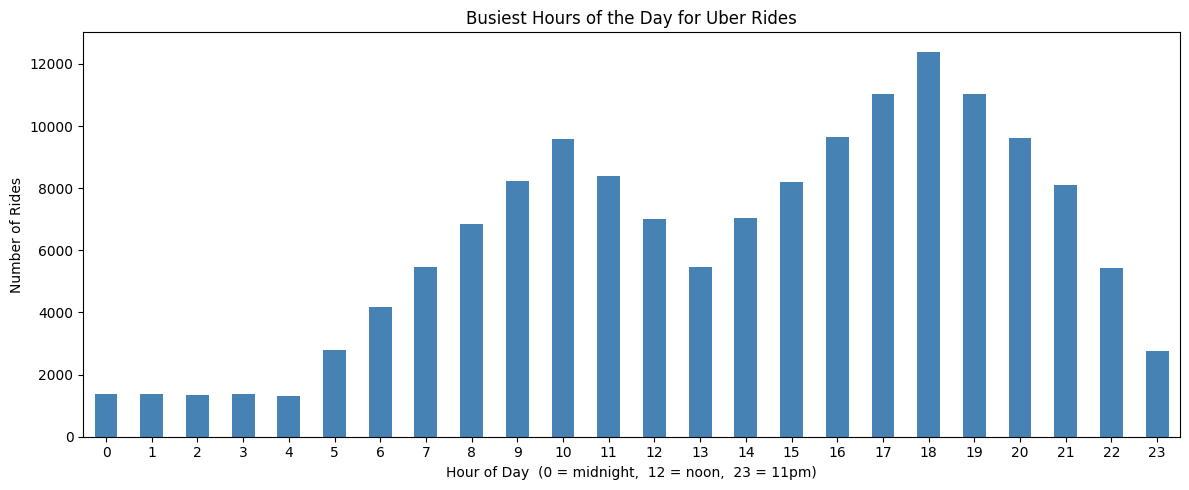

In [19]:
plt.figure(figsize=(12, 5))

hour_counts = data['hour'].value_counts().sort_index()


hour_counts.plot(kind='bar', color='steelblue')

plt.title('Busiest Hours of the Day for Uber Rides')
plt.xlabel('Hour of Day  (0 = midnight,  12 = noon,  23 = 11pm)')
plt.ylabel('Number of Rides')
plt.xticks(rotation=0)  # keep numbers straight, no tilting needed
plt.tight_layout()
plt.savefig('outputs/busiest_hours.png')


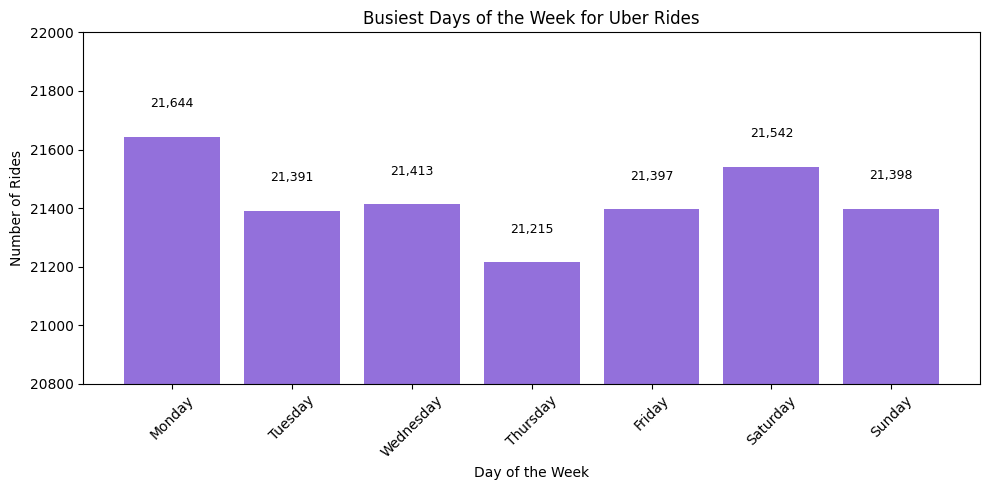

In [23]:
plt.figure(figsize=(10, 5))

day_order = ['Monday', 'Tuesday', 'Wednesday', 
             'Thursday', 'Friday', 'Saturday', 'Sunday']

day_counts = data['weekday'].value_counts().reindex(day_order)



bars = plt.bar(day_order, day_counts, color='mediumpurple')

# add number on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # x position
        height + 100,                         # y position (just above bar)
        f'{int(height):,}',                   # the number with comma formatting
        ha='center', fontsize=9
    )

plt.ylim(20800, 22000)

plt.title('Busiest Days of the Week for Uber Rides')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Rides')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('outputs/busiest_days.png')


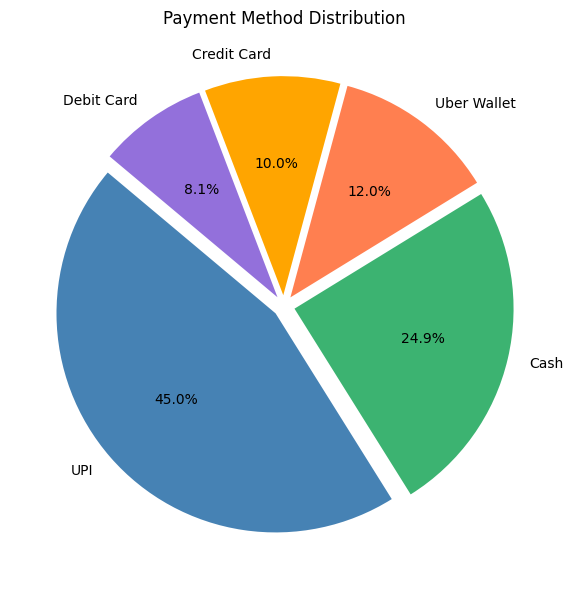

Chart 5 saved!


In [25]:
plt.figure(figsize=(8, 6))

payment_data = data[data['Payment Method'].notna()]
payment_counts = payment_data['Payment Method'].value_counts()

# this automatically creates explode based on however many categories exist
explode = tuple([0.05] * len(payment_counts))

colors = ['steelblue', 'mediumseagreen', 'coral', 
          'orange', 'mediumpurple', 'tomato']

plt.pie(
    payment_counts,
    labels=payment_counts.index,
    colors=colors[:len(payment_counts)],  # use only as many colors as needed
    explode=explode,
    autopct='%1.1f%%',
    startangle=140
)

plt.title('Payment Method Distribution')
plt.tight_layout()
plt.savefig('outputs/payment_pie.png')
plt.show()

print("Chart 5 saved!")

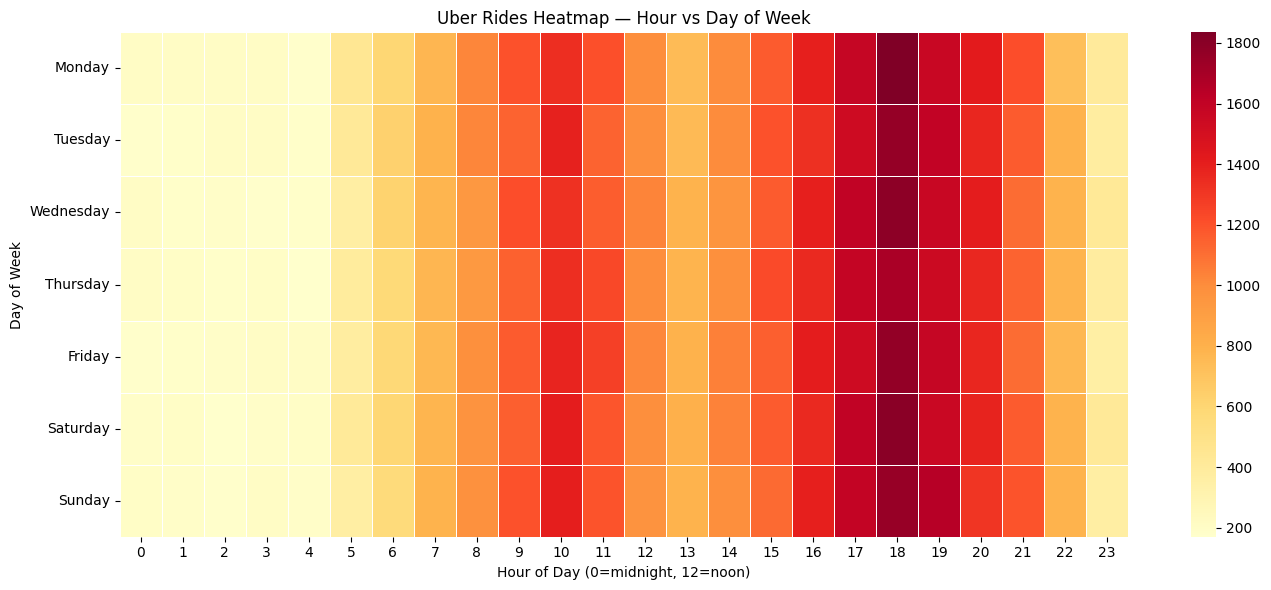

In [26]:
plt.figure(figsize=(14, 6))

day_order = ['Monday', 'Tuesday', 'Wednesday', 
             'Thursday', 'Friday', 'Saturday', 'Sunday']

# create a pivot table — rows=days, columns=hours, values=count of rides
pivot = data.groupby(['weekday', 'hour']).size().unstack()

# reorder days correctly
pivot = pivot.reindex(day_order)

sns.heatmap(
    pivot,
    cmap='YlOrRd',     # color theme — yellow to red
    linewidths=0.5,    # thin lines between cells
    annot=False,       # no numbers inside cells (too crowded)
    fmt='d'
)

plt.title('Uber Rides Heatmap — Hour vs Day of Week')
plt.xlabel('Hour of Day (0=midnight, 12=noon)')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.savefig('outputs/heatmap.png')


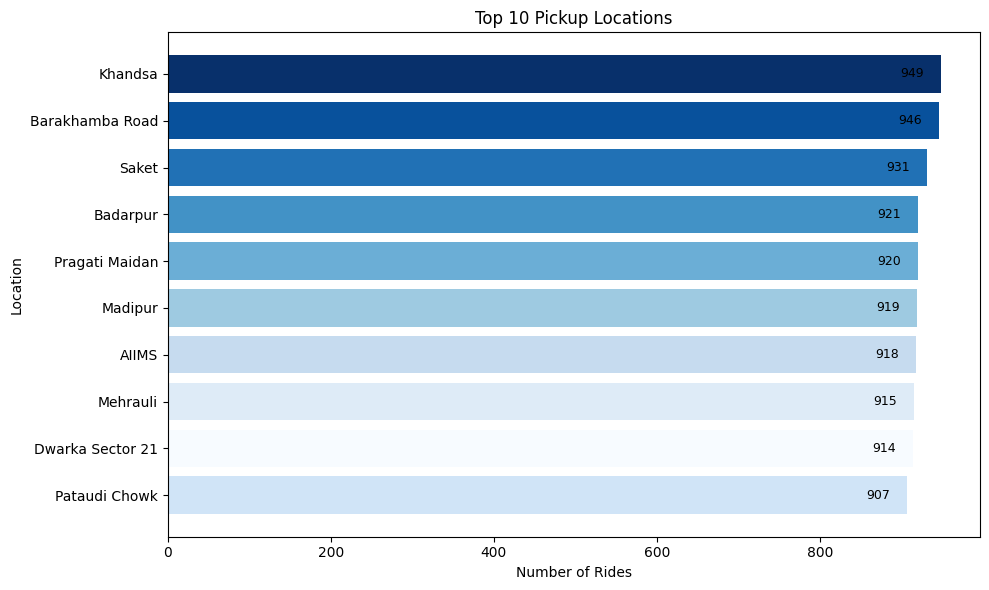

In [28]:
plt.figure(figsize=(10, 6))

top_pickups = data['Pickup Location'].value_counts().head(10)

colors = [
    '#08306b', '#08519c', '#2171b5', '#4292c6', '#6baed6',
    '#9ecae1', '#c6dbef', '#deebf7', '#f7fbff', '#d0e4f7'
]

# horizontal bar chart — easier to read location names
bars = plt.barh(top_pickups.index, top_pickups.values, color=colors)

# add numbers at end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width - 50,
        bar.get_y() + bar.get_height() / 2,
        f'{int(width):,}',
        va='center', fontsize=9
    )

plt.title('Top 10 Pickup Locations')
plt.xlabel('Number of Rides')
plt.ylabel('Location')
plt.gca().invert_yaxis()  # puts number 1 at top
plt.tight_layout()
plt.savefig('outputs/top_pickups.png')
